In [52]:
!pip install easyocr


[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import easyocr
from IPython.display import Image

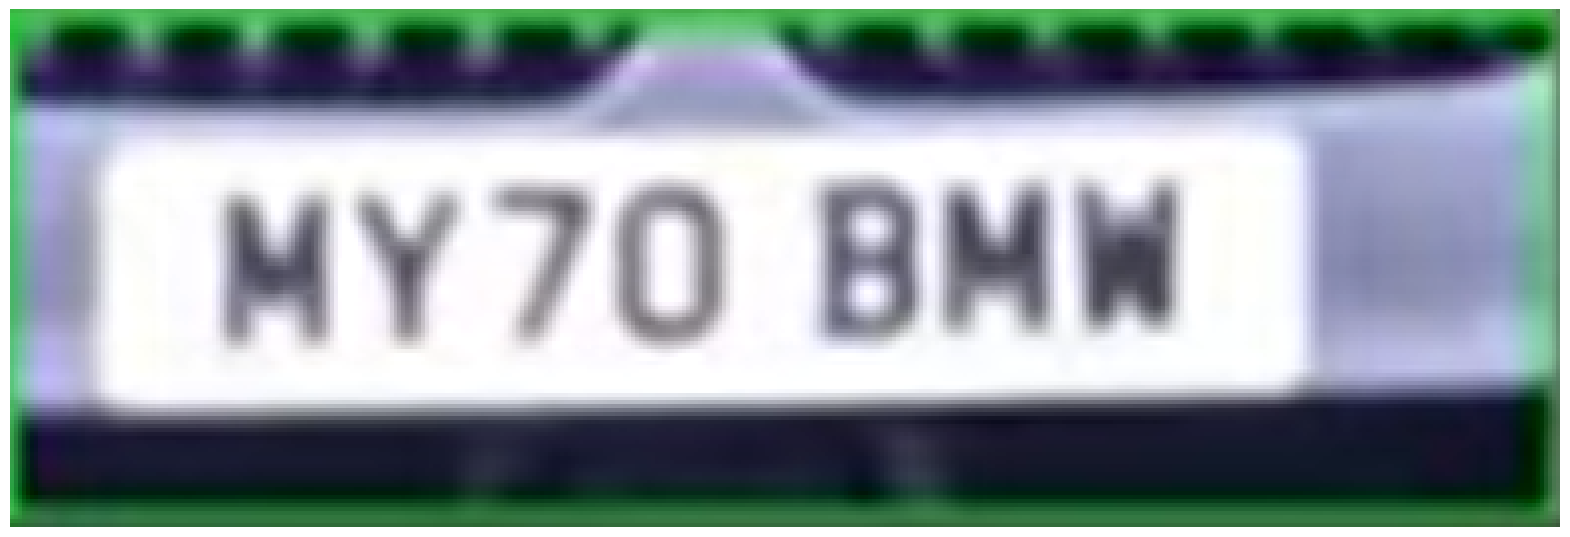

In [54]:
image_path = r"C:\Users\manvi\Downloads\Car-Number-Plates-Detection-main\Car-Number-Plates-Detection-main\plates\scanned_img_4.png"
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [55]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

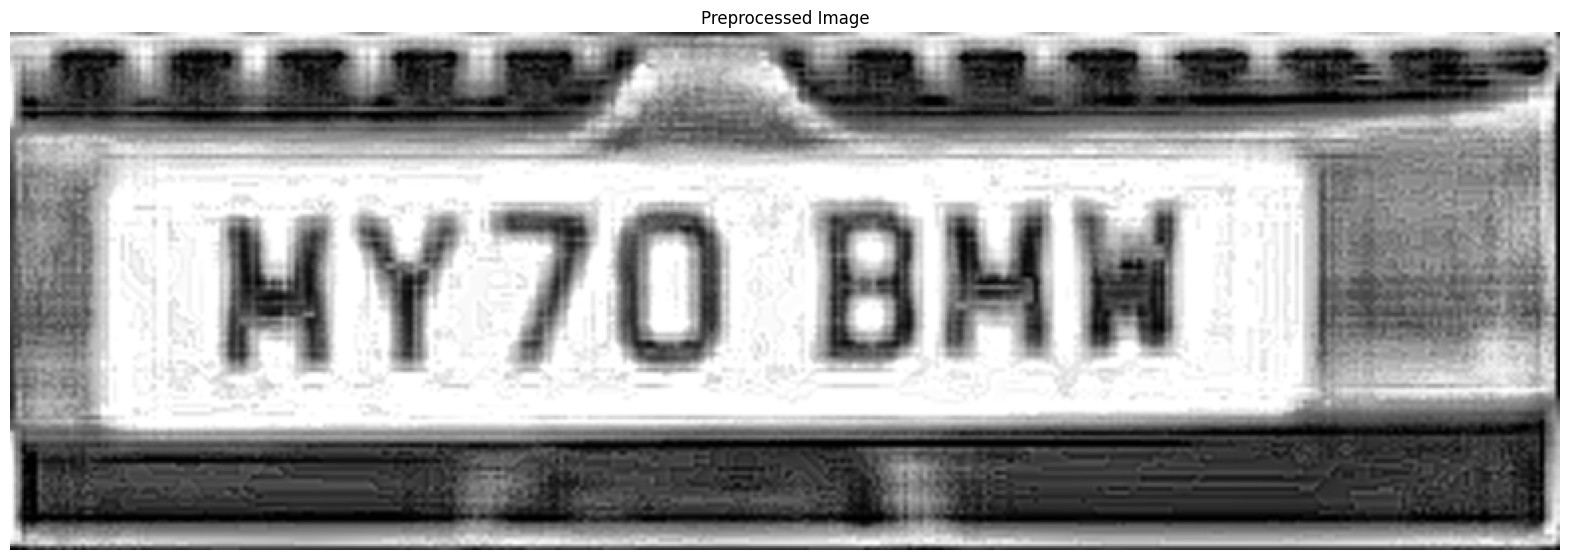

In [56]:
kernel_sharpening = np.array([[-1,-1,-1],
                              [-1, 9,-1],
                              [-1,-1,-1]])
sharpened = cv2.filter2D(gray, -1, kernel_sharpening)

# Step 3: Apply contrast enhancement (CLAHE)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced = clahe.apply(sharpened)

# Step 4: Resize image to improve OCR detection
resized = cv2.resize(enhanced, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# Display the processed image
plt.imshow(resized, cmap='gray')
plt.axis('off')
plt.title("Preprocessed Image")
plt.show()

In [49]:
reader = easyocr.Reader(['en'])
results = reader.readtext(resized)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [51]:
print("Detected Text:")
for (_, text, prob) in results:
    print(f"Text: {text}, Confidence: {prob:.2f}")

Detected Text:
Text: HY7o BHH, Confidence: 0.06
